## 1. What this notebook computes

The previous notebook of this chapter (06a) found $\gamma^\mu\Omega_\mu =
3H\gamma^{(x8)}$ for the author's metric in the DIAGONAL vielbein. A vielbein is a
choice: at every point any other set of eight perpendicular unit directions
describes the same metric. This notebook asks which results depend on that choice
and which do not. It

- builds a second vielbein of the same metric, the diagonal one **boosted** in the
  plane of the time $x4$ and the hidden direction $x8$ by a rapidity
  $b = \beta x_4 + b_0$ that grows with the time;
- computes its canonical spin connection and finds exactly
  $\gamma'^\mu\Omega'_\mu = \frac{6H - \beta}{2}\big(\cosh b\,\gamma^{(x8)} -
  \sinh b\,\gamma^{(x4)}\big)$, which VANISHES for $\beta = 6H$, although
  $\Omega'_\mu$ itself does not vanish;
- explains the formula with the **local spin covariance** of the connection,
  using the explicit spinor boost $R = \cosh\frac{b}{2} -
  \sinh\frac{b}{2}\,\gamma^{(x4)}\gamma^{(x8)}$;
- computes the Riemann and Ricci tensors and the curvature
  $F_{\mu\nu}$ of the spinor connection, checks $F_{\mu\nu} =
  \frac12 R_{ab\mu\nu}S^{ab}$ in all 28 coordinate planes, and shows that this
  curvature, which no choice of frame can remove, is nonzero for every $H > 0$;
- shows that the rescaled field $\chi = \sin^{1/2}(z)\,\Psi$ obeys an equation
  without the term $3H\gamma^{(x8)}$;
- checks every result against the Revision records and draws six teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 06b (What depends on the frame: boosts, spin covariance, curvature, rescaling)
is the file `Revision/textbook/notebooks/06b_frame_dependence.ipynb` of the repository
Dirac_claude. For the author's metric it boosts the diagonal vielbein in the (x4, x8)
plane with a time-dependent rapidity and computes exactly, with sympy, the new spin
connection and the new contraction gamma^mu Omega_mu = ((6 H - beta)/2) (cosh b
gamma^(x8) - sinh b gamma^(x4)), which vanishes identically for the rapidity rate beta =
6 H; it verifies the local spin covariance of the connection with an explicit spinor
boost, computes the Riemann and Ricci tensors and the curvature of the spinor connection,
which no frame can remove, shows that the rescaling Psi = sin^(-1/2)(z) chi removes the
term 3 H gamma^(x8), checks every result against the Revision records and draws six
teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 06b_frame_dependence.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 1 minute on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 06b_frame_dependence.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
06b_frame_dependence.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/06b.captions.json`,
`Revision/textbook/figures/06b_1_boost_hyperbolas.png`,
`Revision/textbook/figures/06b_2_boosted_contraction.png`,
`Revision/textbook/figures/06b_3_boosted_connection_heat_maps.png`,
`Revision/textbook/figures/06b_4_ricci_components.png`,
`Revision/textbook/figures/06b_5_spinor_curvature_norms.png` and
`Revision/textbook/figures/06b_6_rescaling.png`. It changes no other file of the
repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files exist
    ALL 26 CHECKS PASSED (notebook 06b)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/06b_frame_dependence.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for Revision/algebra/gammas.json or for a report: the notebook
  reads Revision records from the repository; open it inside the folder
  Revision/textbook/notebooks of a complete copy of the repository Dirac_claude (a single
  downloaded notebook file is not enough).
- a cell runs for several minutes: the exact algebra of sympy with hyperbolic functions
  is slow on old computers; the whole notebook needs about a minute on a 2024 laptop.
  Wait, or close other programs that use the processor.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 06b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 06b (What depends on the frame: boosts, spin covariance, curvature, rescaling)
# is the file Revision/textbook/notebooks/06b_frame_dependence.ipynb of the repository
# Dirac_claude. For the author's metric it boosts the diagonal vielbein in the (x4, x8)
# plane with a time-dependent rapidity and computes exactly, with sympy, the new spin
# connection and the new contraction gamma^mu Omega_mu = ((6 H - beta)/2) (cosh b
# gamma^(x8) - sinh b gamma^(x4)), which vanishes identically for the rapidity rate beta
# = 6 H; it verifies the local spin covariance of the connection with an explicit spinor
# boost, computes the Riemann and Ricci tensors and the curvature of the spinor
# connection, which no frame can remove, shows that the rescaling Psi = sin^(-1/2)(z) chi
# removes the term 3 H gamma^(x8), checks every result against the Revision records and
# draws six teaching plots. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 06b_frame_dependence.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 1 minute
# on a typical laptop. Scroll to the end and compare the last printed lines with the
# lines in the step "What the notebook writes and what you must see" below. To keep the
# results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose the
# menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 06b_frame_dependence.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 06b_frame_dependence.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/06b.captions.json,
# Revision/textbook/figures/06b_1_boost_hyperbolas.png,
# Revision/textbook/figures/06b_2_boosted_contraction.png,
# Revision/textbook/figures/06b_3_boosted_connection_heat_maps.png,
# Revision/textbook/figures/06b_4_ricci_components.png,
# Revision/textbook/figures/06b_5_spinor_curvature_norms.png and
# Revision/textbook/figures/06b_6_rescaling.png. It changes no other file of the
# repository; running it headless or saving it in JupyterLab also rewrites the notebook
# file itself. It does not use the internet while it runs. The files it writes are the
# same files that are stored in the repository (on another computer a figure may differ
# in a few bytes, which is harmless). To get the stored versions back, run this command
# in the repository folder (it also undoes every change you made yourself in the folder
# Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files exist
#     ALL 26 CHECKS PASSED (notebook 06b)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/06b_frame_dependence.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for Revision/algebra/gammas.json or for a report: the notebook
#   reads Revision records from the repository; open it inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository Dirac_claude (a
#   single downloaded notebook file is not enough).
# - a cell runs for several minutes: the exact algebra of sympy with hyperbolic functions
#   is slow on old computers; the whole notebook needs about a minute on a 2024 laptop.
#   Wait, or close other programs that use the processor.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "06b"  # this notebook: chapter 06, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 06b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Vielbein** $e^a{}_\mu$: eight perpendicular unit directions at every point
  (frame index $a$, coordinate index $\mu$), with $g_{\mu\nu} = \sum_a \eta_{aa}
  e^a{}_\mu e^a{}_\nu$; $\eta = \mathrm{diag}(+1,+1,+1,-1,-1,-1,-1,+1)$ in the
  order $x1, \dots, x8$.
- **Frame rotation** (local Lorentz transformation): a new vielbein
  $e'^a{}_\mu = \sum_b \Lambda^a{}_b(x)\,e^b{}_\mu$ with a matrix $\Lambda(x)$
  that keeps $\eta$: $\Lambda^T\eta\Lambda = \eta$. It describes the same metric.
- **Boost**: a frame rotation that mixes one space-like and one time-like
  direction. In the plane of the time $x4$ (time-like) and the hidden direction
  $x8$ (space-like) it is $e'^{(x4)} = \cosh b\, e^{(x4)} + \sinh b\, e^{(x8)}$,
  $e'^{(x8)} = \sinh b\, e^{(x4)} + \cosh b\, e^{(x8)}$.
- **Rapidity** $b$: the "angle" of a boost. **Hyperbolic functions**:
  $\cosh b = (e^b + e^{-b})/2$ and $\sinh b = (e^b - e^{-b})/2$; they satisfy
  $\cosh^2 b - \sinh^2 b = 1$, just as $\cos^2 + \sin^2 = 1$ for rotations.
- **Spin connection** $\omega_{\mu ab}$, **spinor connection** $\Omega_\mu =
  \frac12\sum_{a,b}\omega_{\mu ab}S^{ab}$ with $S^{ab} = \frac14[\gamma^a,
  \gamma^b]$, **curved gammas** $\gamma^\mu = \sum_a e_a{}^\mu\gamma^a$,
  **covariant derivative** $D_\mu = \partial_\mu + \Omega_\mu$: as in Notebook
  06a. A prime marks the quantities of the boosted vielbein.
- **Spinor boost** $R(x)$: a 16 x 16 matrix that turns spinors when the frame is
  boosted; it **covers** $\Lambda$ when $R^{-1}\gamma^a R = \sum_b \Lambda^a{}_b
  \gamma^b$ for every $a$.
- **Riemann tensor** $R^\rho{}_{\sigma\mu\nu}$: the measure of curvature, built
  from the Christoffel symbols and their derivatives; it is zero everywhere only
  for a flat space. **Ricci tensor** $R_{\sigma\nu} = \sum_\rho
  R^\rho{}_{\sigma\rho\nu}$, mixed form $R^\mu{}_\nu = \sum_\sigma g^{\mu\sigma}
  R_{\sigma\nu}$, **Ricci scalar** $R = \sum_\mu R^\mu{}_\mu$.
- **Curvature of the spinor connection** $F_{\mu\nu} = \partial_\mu\Omega_\nu -
  \partial_\nu\Omega_\mu + [\Omega_\mu, \Omega_\nu]$: the 16 x 16 matrix with
  $D_\mu D_\nu\Psi - D_\nu D_\mu\Psi = F_{\mu\nu}\Psi$.
- **Frame-dependent**: a quantity whose value changes when the vielbein is
  changed (such as $\gamma^\mu\Omega_\mu$). **Frame-independent**: a statement
  that holds in every vielbein (such as "$F_{\mu\nu}$ is not zero").
- **Rescaling**: writing the field as a known function times a new field,
  $\Psi = w(x)\,\chi$, and deriving the equation that $\chi$ obeys.
- **Exact** check: sympy proves that an expression is zero for ALL values of its
  symbols. **Heat map**: a picture of a matrix, red positive, blue negative,
  white zero.

## 4. The physical and mathematical situation

The metric is the author's, with $z = 6Hx_8$ in $(0, \pi/2)$, $H > 0$ and an
arbitrary function $a_4(x_4)$:

$$g = \mathrm{diag}\big(e^{2a_4}\sin^{1/3}z\ (\times 3),\ -1,\
-e^{-2a_4}\sin^{1/3}z\ (\times 3),\ \cot^2 z\big).$$

The diagonal vielbein has the factors $f = (e^{a_4}s\ (\times 3),\ 1,\
e^{-a_4}s\ (\times 3),\ \cot z)$, $s = \sin^{1/6}z$. The canonical spin
connection of ANY vielbein $e$ is $\omega_\mu{}^a{}_b = \sum_\nu e^a{}_\nu
(\partial_\mu e_b{}^\nu + \sum_\lambda\Gamma^\nu{}_{\mu\lambda}e_b{}^\lambda)$.

**The theorem behind this notebook (local spin covariance).** If $e' = \Lambda e$
and the spinor matrix $R(x)$ covers $\Lambda(x)$, then

$$\Omega'_\mu = R\,\Omega_\mu R^{-1} - (\partial_\mu R)R^{-1}, \qquad
\gamma'^\mu = R\,\gamma^\mu R^{-1}, \qquad F'_{\mu\nu} = R\,F_{\mu\nu}R^{-1}.$$

Multiplying the first two and summing over $\mu$ gives

$$\gamma'^\mu\Omega'_\mu = R\,(\gamma^\mu\Omega_\mu)\,R^{-1} -
\sum_\mu\gamma'^\mu(\partial_\mu R)R^{-1}.$$

The second term can cancel the first: the contraction $\gamma^\mu\Omega_\mu$ is
frame-dependent. The curvature only gets turned by $R$, so if $F_{\mu\nu} \ne 0$
in one frame, it is nonzero in every frame: no frame removes the spinor
connection itself.

**Status.** Every statement checked below is PROVED exactly (sympy, symbolic $H$,
$a_4$, $\beta$, $b_0$) and reproduces the Revision record where the record states
it. This is the record's own correction of the non-triviality statement: the
value $3H\gamma^{(x8)}$ belongs to the diagonal vielbein; what is
frame-independent is the curvature.

## 5. The tools: sympy, the author's gammas and the general formulas

This notebook repeats the tools of Notebook 06a, so that it runs on its own. The
next cell reads the author's gammas and the matrix $C$ from
`Revision/algebra/gammas.json`, checks the 64 Clifford relations, builds the 28
matrices $S^{ab}$, and defines the exact zero test `is_zero` (first a fast route
through exponential functions, then sympy's `simplify`; it never calls a nonzero
expression zero) and `record_passed`, which reads a Revision report and tells
whether a check is recorded as passed.

In [2]:
import numpy as np  # decimal numbers for the plots
import sympy as sp  # exact algebra and calculus with symbols
from sympy.parsing.mathematica import parse_mathematica  # reads Wolfram notation

fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
NAMES = fixture["coordinates"]  # ["x1", ..., "x8"]
ETA = fixture["eta"]  # +1 space-like, -1 time-like
gamma = [sp.Matrix(rows) for rows in fixture["gamma"]]  # gamma[a] = gamma^(x(a+1))
C = sp.Matrix(fixture["C"])  # the author's C (Dirac adjoint Psibar = Psi^dagger C)
I16, Z16 = sp.eye(16), sp.zeros(16, 16)
check(all(gamma[a] * gamma[b] + gamma[b] * gamma[a]
          == (2 * ETA[a] if a == b else 0) * I16
          for a in range(8) for b in range(8)),
      "the 64 Clifford relations of the author's gammas")
S = [[(gamma[a] * gamma[b] - gamma[b] * gamma[a]) / 4 for b in range(8)]
     for a in range(8)]


def is_zero(expr):
    """True when expr is exactly zero for all values of its symbols."""
    expr = sp.sympify(expr)
    if expr == 0:
        return True
    if sp.cancel(sp.expand(expr.rewrite(sp.exp))) == 0:  # the fast route
        return True
    return sp.simplify(expr) == 0  # the slower general route


def matrix_is_zero(matrix):
    return all(is_zero(entry) for entry in matrix)


def record_passed(path, name):
    """True when the Revision report at path records the check name as passed."""
    data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in data["checks"]:
        if entry["name"] == name:
            return entry["verdict"].upper() == "PASS"
    raise KeyError(f"{path} has no check {name}")


SCOPE_PY = "Revision/theory/reports/python-scope.json"
SCOPE_WL = "Revision/theory/reports/wolfram-scope.json"
REPORT_PY = "Revision/theory/reports/python-field-theory.json"
REPORT_WL = "Revision/theory/reports/wolfram-field-theory.json"
THEORY_FILE = "Revision/theory/field-theory.json"

PASS the 64 Clifford relations of the author's gammas


The next cell defines the four general formulas as Python functions, exactly as
in Notebook 06a: `christoffel(g, coords)` gives $\Gamma^l{}_{mn}$;
`spin_connection(e, Gam, coords, eta)` gives $\omega_{\mu ab}$ for any vielbein
matrix `e` (row = frame index, column = coordinate; its inverse `E = e.inv()` has
`E[nu, b]` $= e_b{}^\nu$); `spinor_connection(omega, S)` gives $\Omega_\mu =
\sum_{a<b}\omega_{\mu ab}S^{ab}$; `curved_gammas(e, gammas)` gives $\gamma^\mu =
\sum_a e_a{}^\mu\gamma^a$. For the boosted vielbein the entries contain
$\cosh$ and $\sinh$; `spin_connection` simplifies every entry, which is the
slowest step of the notebook (some seconds).

In [3]:
def christoffel(g, coords):
    """Gam[l][m][n] = (1/2) sum_r g^lr (d_m g_rn + d_n g_rm - d_r g_mn)."""
    n = len(coords)
    g_inv = g.inv()
    Gam = [[[sp.Integer(0)] * n for _ in range(n)] for _ in range(n)]
    for l in range(n):
        for m in range(n):
            for k in range(m, n):
                value = sum(g_inv[l, r] * (sp.diff(g[r, k], coords[m])
                                           + sp.diff(g[r, m], coords[k])
                                           - sp.diff(g[m, k], coords[r]))
                            for r in range(n) if g_inv[l, r] != 0) / 2
                Gam[l][m][k] = Gam[l][k][m] = sp.simplify(value)
    return Gam


def spin_connection(e, Gam, coords, eta):
    """omega[mu][a][b] = eta_aa sum_nu e^a_nu (d_mu e_b^nu + Gam^nu_mu,lam e_b^lam)."""
    n = len(coords)
    E = e.inv()  # E[nu, b] = e_b^nu
    omega = [[[sp.Integer(0)] * n for _ in range(n)] for _ in range(n)]
    for mu in range(n):
        for a in range(n):
            for b in range(n):
                mixed = 0
                for nu in range(n):
                    if e[a, nu] == 0:
                        continue
                    mixed += e[a, nu] * (sp.diff(E[nu, b], coords[mu]) + sum(
                        Gam[nu][mu][lam] * E[lam, b] for lam in range(n)))
                omega[mu][a][b] = sp.simplify(eta[a] * mixed)
    return omega


def spinor_connection(omega, S):
    """Omega[mu] = sum_{a<b} omega_{mu ab} S^ab."""
    n = len(omega)
    size = S[0][0].shape[0]
    return [sum((omega[mu][a][b] * S[a][b] for a in range(n)
                 for b in range(a + 1, n) if omega[mu][a][b] != 0),
                sp.zeros(size, size)) for mu in range(n)]


def curved_gammas(e, gammas):
    """gamma^mu = sum_a e_a^mu gamma^a."""
    E = e.inv()
    return [sum((E[mu, a] * gammas[a] for a in range(len(gammas))),
                sp.zeros(*gammas[0].shape)) for mu in range(len(gammas))]


say("defined: christoffel, spin_connection, spinor_connection, curved_gammas")

defined: christoffel, spin_connection, spinor_connection, curved_gammas


## 6. The diagonal vielbein again (the control)

The next cell makes the symbols of the metric ($x1, \dots, x8$, $H > 0$, the
function $a_4(x_4)$, $z = 6Hx_8$), the diagonal vielbein, the Christoffel symbols,
the spin connection, $\Omega_\mu$ and the curved gammas, and checks the result of
Notebook 06a, $\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$. This is the CONTROL of the
boosted computation: the same code, with no boost, must give the known value.

In [4]:
x = sp.symbols("x1:9", real=True)
x4, x8 = x[3], x[7]
H = sp.Symbol("H", positive=True)
a4 = sp.Function("a4")(x4)  # any function of the time
z = 6 * H * x8
s = sp.sin(z) ** sp.Rational(1, 6)
f = [sp.exp(a4) * s] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * s] * 3 + [sp.cot(z)]
g = sp.diag(*[ETA[a] * f[a] ** 2 for a in range(8)])  # the author's metric
e = sp.diag(*f)  # the diagonal vielbein
Gam = christoffel(g, x)
omega = spin_connection(e, Gam, x, ETA)
Omega = spinor_connection(omega, S)
gup = curved_gammas(e, gamma)
slash = sum((gup[mu] * Omega[mu] for mu in range(8)), Z16)
check(matrix_is_zero(slash - 3 * H * gamma[7]),
      "control: the diagonal vielbein gives gamma^mu Omega_mu = 3 H gamma^(x8)",
      record=f"{SCOPE_PY}, check rescaling_removes_the_connection_term")

PASS control: the diagonal vielbein gives gamma^mu Omega_mu = 3 H gamma^(x8)
     reproduces Revision/theory/reports/python-scope.json, check
    rescaling_removes_the_connection_term


## 7. A boost of the frame in the plane of $x4$ and $x8$

The next cell writes the boost matrix $\Lambda(b)$: the identity, except in the
rows and columns of $x4$ (position 3) and $x8$ (position 7), where it is
$\begin{pmatrix}\cosh b & \sinh b\\ \sinh b & \cosh b\end{pmatrix}$. It checks
that $\Lambda^T\eta\Lambda = \eta$ for EVERY rapidity $b$; in the $(x4, x8)$
block this is $-\cosh^2 b + \sinh^2 b = -1$, $\cosh^2 b - \sinh^2 b = +1$ and
$-\cosh b\sinh b + \sinh b\cosh b = 0$. It also checks that the inverse boost is
the boost with $-b$.

In [5]:
def boost(b):
    """The 8 x 8 boost matrix Lambda(b) in the plane of x4 (index 3) and x8 (7)."""
    L = sp.eye(8)
    L[3, 3], L[3, 7], L[7, 3], L[7, 7] = sp.cosh(b), sp.sinh(b), sp.sinh(b), sp.cosh(b)
    return L


b_symbol = sp.Symbol("b", real=True)  # a rapidity
eta_matrix = sp.diag(*ETA)
L_test = boost(b_symbol)
check(matrix_is_zero(L_test.T * eta_matrix * L_test - eta_matrix),
      "Lambda(b)^T eta Lambda(b) = eta for every rapidity b")
check(matrix_is_zero(L_test * boost(-b_symbol) - sp.eye(8)),
      "the inverse of the boost with rapidity b is the boost with -b")

PASS Lambda(b)^T eta Lambda(b) = eta for every rapidity b
PASS the inverse of the boost with rapidity b is the boost with -b


The next cell draws what a boost does to the two frame directions $e^{(x4)}$ and
$e^{(x8)}$, drawn with their $x4$ component horizontally and their $x8$ component
vertically, for the rapidities $b = 0, 0.5, 1$. A rotation would move them along
a circle; a boost moves them along the two **unit hyperbolas** $t^2 - y^2 = 1$
(where every vector has $\eta$-length $-1$, like the time direction) and
$y^2 - t^2 = 1$ ($\eta$-length $+1$, like the hidden direction). Both arrows tilt
towards the diagonal line $t = y$ (the "light line"), and they stay perpendicular
in the sense of $\eta$.

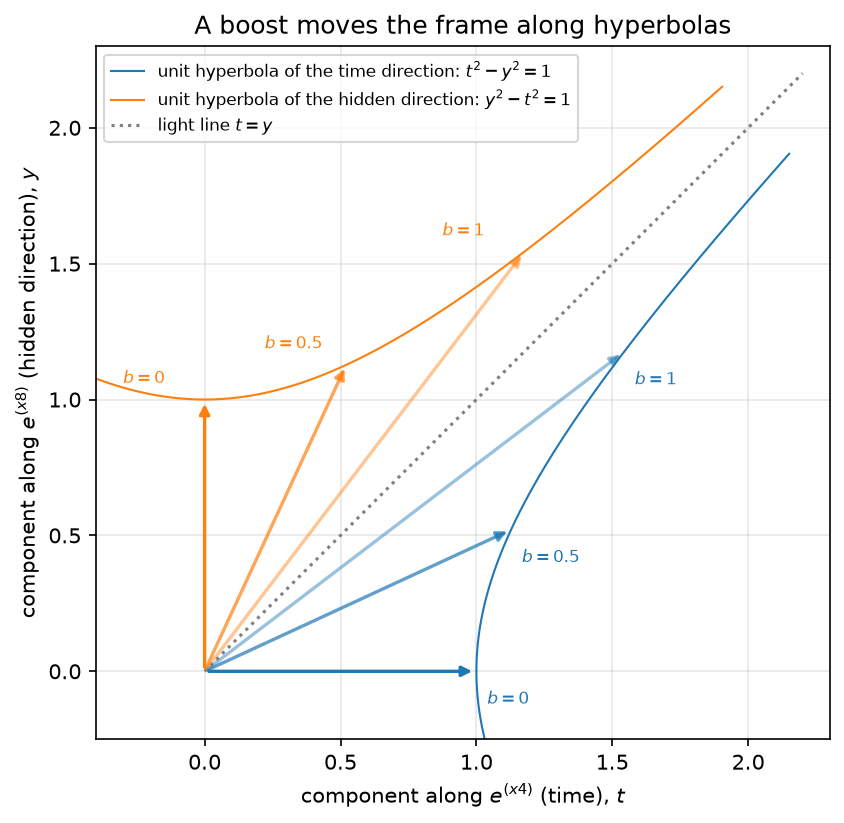

Figure 06b.1 saved as Revision/textbook/figures/06b_1_boost_hyperbolas.png


In [6]:
fig, ax = plt.subplots(figsize=(6.4, 6.0))
rapidity = np.linspace(-1.4, 1.4, 200)
ax.plot(np.cosh(rapidity), np.sinh(rapidity), color="tab:blue", linewidth=1.0,
        label="unit hyperbola of the time direction: $t^2 - y^2 = 1$")
ax.plot(np.sinh(rapidity), np.cosh(rapidity), color="tab:orange", linewidth=1.0,
        label="unit hyperbola of the hidden direction: $y^2 - t^2 = 1$")
ax.plot([0, 2.2], [0, 2.2], ":", color="gray", label="light line $t = y$")
for b_value, alpha in ((0.0, 1.0), (0.5, 0.7), (1.0, 0.45)):
    c_b, s_b = np.cosh(b_value), np.sinh(b_value)
    ax.annotate("", xy=(c_b, s_b), xytext=(0, 0), arrowprops=dict(
        arrowstyle="-|>", color="tab:blue", alpha=alpha, linewidth=1.6))
    ax.annotate("", xy=(s_b, c_b), xytext=(0, 0), arrowprops=dict(
        arrowstyle="-|>", color="tab:orange", alpha=alpha, linewidth=1.6))
    ax.text(c_b + 0.04, s_b - 0.12, f"$b = {b_value:g}$", fontsize=8,
            color="tab:blue")
    ax.text(s_b - 0.30, c_b + 0.06, f"$b = {b_value:g}$", fontsize=8,
            color="tab:orange")
ax.set_xlim(-0.4, 2.3)
ax.set_ylim(-0.25, 2.3)
ax.set_aspect("equal")
ax.set_xlabel("component along $e^{(x4)}$ (time), $t$")
ax.set_ylabel("component along $e^{(x8)}$ (hidden direction), $y$")
ax.set_title("A boost moves the frame along hyperbolas")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "boost_hyperbolas",
            "A boost of the frame in the plane of the time $x4$ and the hidden "
            "direction $x8$. The boosted frame directions $e'^{(x4)} = \\cosh b\\, "
            "e^{(x4)} + \\sinh b\\, e^{(x8)}$ (blue arrows) and $e'^{(x8)} = "
            "\\sinh b\\, e^{(x4)} + \\cosh b\\, e^{(x8)}$ (orange arrows) for the "
            "rapidities $b = "
            "0, 0.5, 1$ (fainter for larger $b$), drawn with their $x4$ component $t$ "
            "horizontally and their $x8$ component $y$ vertically (pure numbers). "
            "They move along the unit hyperbolas $t^2 - y^2 = 1$ and $y^2 - t^2 = 1$ "
            "and tilt symmetrically towards the light line $t = y$ (dotted).")

## 8. The boosted vielbein and its canonical spin connection

Now the rapidity depends on the time: $b = \beta x_4 + b_0$ with two constants
$\beta$ (the rate) and $b_0$ (the starting value). The boosted vielbein is the
matrix product $e' = \Lambda(b)\,e$. The next cell checks that it describes the
author's metric (all 64 entries of $e'^T\eta e'$), computes its canonical spin
connection, and checks the vielbein postulate (512 equations) and the
antisymmetry $\omega'_{\mu ab} = -\omega'_{\mu ba}$. These are the record's checks
`boosted_frame_reproduces_metric` and `boosted_frame_canonical_connection`.

In [7]:
beta, b0 = sp.symbols("beta b0", real=True)  # the rate and the start of the rapidity
b = beta * x4 + b0  # the rapidity grows with the time
L = boost(b)
e_boosted = L * e  # e'^a_mu = sum_c Lambda^a_c e^c_mu
check(matrix_is_zero(e_boosted.T * eta_matrix * e_boosted - g),
      "the boosted vielbein gives the author's metric (64 entries)",
      record=f"{SCOPE_PY}, check boosted_frame_reproduces_metric")
omega_b = spin_connection(e_boosted, Gam, x, ETA)  # omega'_{mu ab}
postulate = [sp.diff(e_boosted[a, nu], x[mu])
             - sum(Gam[lam][mu][nu] * e_boosted[a, lam] for lam in range(8))
             + sum(ETA[a] * omega_b[mu][a][c] * e_boosted[c, nu] for c in range(8))
             for mu in range(8) for a in range(8) for nu in range(8)]
antisymmetric = all(is_zero(omega_b[mu][a][c] + omega_b[mu][c][a])
                    for mu in range(8) for a in range(8) for c in range(8))
check(all(is_zero(v) for v in postulate) and antisymmetric,
      "boosted vielbein: vielbein postulate (512) and antisymmetry of omega'",
      record=f"{SCOPE_PY}, check boosted_frame_canonical_connection")
Omega_b = spinor_connection(omega_b, S)  # Omega'_mu
gup_b = curved_gammas(e_boosted, gamma)  # gamma'^mu
count_b = sum(1 for mu in range(8) for a in range(8) for c in range(a + 1, 8)
              if omega_b[mu][a][c] != 0)
say(f"nonzero components omega'_mu ab with a < b: {count_b}")

PASS the boosted vielbein gives the author's metric (64 entries)
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_reproduces_metric
PASS boosted vielbein: vielbein postulate (512) and antisymmetry of omega'
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_canonical_connection
nonzero components omega'_mu ab with a < b: 13


## 9. The contraction in the boosted vielbein

The next cell computes $\gamma'^\mu\Omega'_\mu$ (summed over $\mu$) and compares it
with the record's formula

$$\gamma'^\mu\Omega'_\mu = \frac{6H - \beta}{2}\big(\cosh b\,\gamma^{(x8)} -
\sinh b\,\gamma^{(x4)}\big),$$

exactly, for symbolic $a_4$, $H$, $\beta$ and $b_0$. At $b = 0$ (no boost) the
formula gives back $3H\gamma^{(x8)}$. The coefficient $(6H - \beta)/2$ already
shows the surprise: for the rate $\beta = 6H$ the contraction is zero.

In [8]:
slash_b = sum((gup_b[mu] * Omega_b[mu] for mu in range(8)), Z16)
formula = (6 * H - beta) / 2 * (sp.cosh(b) * gamma[7] - sp.sinh(b) * gamma[3])
check(matrix_is_zero(slash_b - formula),
      "gamma'^mu Omega'_mu = ((6H - beta)/2)(cosh b gamma^(x8) - sinh b gamma^(x4))",
      record=f"{SCOPE_PY}, check boosted_frame_gammaOmega_formula")
check(formula.subs({beta: 0, b0: 0}) == 3 * H * gamma[7],
      "with no boost (beta = b0 = 0) the formula is 3 H gamma^(x8)")

PASS gamma'^mu Omega'_mu = ((6H - beta)/2)(cosh b gamma^(x8) - sinh b gamma^(x4))
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_gammaOmega_formula
PASS with no boost (beta = b0 = 0) the formula is 3 H gamma^(x8)


The next cell draws the two coefficients of the formula, the coefficient of
$\gamma^{(x8)}$, $\frac{6H-\beta}{2}\cosh b$, and the coefficient of
$\gamma^{(x4)}$, $-\frac{6H-\beta}{2}\sinh b$, as functions of the time $x_4$, for
$b_0 = 0$, $H = 1$ and the four rates $\beta = 0, 3, 6, 9$. The curves are made
from the formula that the previous cell proved. For $\beta = 0$ they are the
constants $3$ and $0$ of the diagonal vielbein; for $\beta = 6$ both are zero at
every time; for $\beta = 9$ they change sign.

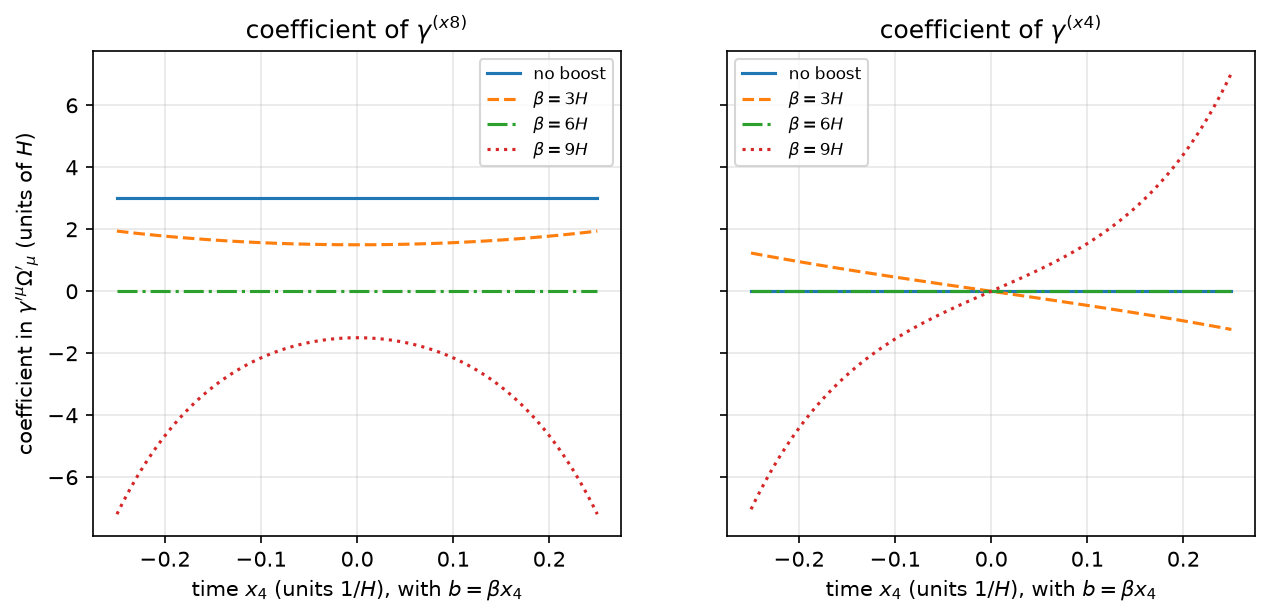

Figure 06b.2 saved as Revision/textbook/figures/06b_2_boosted_contraction.png


In [9]:
times = np.linspace(-0.25, 0.25, 101)
t_symbol = sp.Symbol("t", real=True)
coefficient_x8 = (6 * H - beta) / 2 * sp.cosh(b)  # the coefficient of gamma^(x8)
coefficient_x4 = -(6 * H - beta) / 2 * sp.sinh(b)  # the coefficient of gamma^(x4)
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)
for rate, style in ((0, "-"), (3, "--"), (6, "-."), (9, ":")):
    values = {H: 1, beta: rate, b0: 0, x4: t_symbol}
    c8 = sp.lambdify(t_symbol, coefficient_x8.subs(values))
    c4 = sp.lambdify(t_symbol, coefficient_x4.subs(values))
    ax_left.plot(times, np.broadcast_to(c8(times), times.shape), style,
                 label=f"$\\beta = {rate}H$" if rate else "no boost")
    ax_right.plot(times, np.broadcast_to(c4(times), times.shape), style,
                  label=f"$\\beta = {rate}H$" if rate else "no boost")
ax_left.set_title("coefficient of $\\gamma^{(x8)}$")
ax_right.set_title("coefficient of $\\gamma^{(x4)}$")
for ax in (ax_left, ax_right):
    ax.set_xlabel("time $x_4$ (units $1/H$), with $b = \\beta x_4$")
    ax.legend(fontsize=8)
ax_left.set_ylabel("coefficient in $\\gamma'^\\mu\\Omega'_\\mu$ (units of $H$)")
save_figure(fig, "boosted_contraction",
            "The contraction $\\gamma'^\\mu\\Omega'_\\mu$ in the boosted vielbein with "
            "rapidity $b = \\beta x_4$ and $H = 1$: the coefficient of "
            "$\\gamma^{(x8)}$ (left) and of $\\gamma^{(x4)}$ (right) versus the time "
            "$x_4$ in units $1/H$, for the rates $\\beta = 0, 3H, 6H, 9H$. For "
            "$\\beta = 0$ (no boost) the coefficients are $3$ and $0$, the diagonal "
            "value $3H\\gamma^{(x8)}$; for $\\beta = 6H$ both vanish at every time; "
            "the same metric, a different frame, a different value.")

## 10. The rate $\beta = 6H$: the contraction vanishes, the connection does not

The next cell puts $\beta = 6H$ into the boosted spin connection (substituting
after the computation is allowed, because the computation was done for every
$\beta$) and checks the record's statement: $\gamma'^\mu\Omega'_\mu = 0$
identically, for every $H > 0$ and every $a_4$, while $\Omega'_\mu$ is nonzero for
$\mu = x1, \dots, x7$ and zero only for $\mu = x8$. So in this vielbein the field
equation $\gamma'^\mu D'_\mu\Psi' = (m + U')\Psi'$ has no term $\gamma'^\mu
\Omega'_\mu\Psi'$ at all, although the spinor connection is everywhere.

In [10]:
six_H = {beta: 6 * H}
slash_6H = slash_b.subs(six_H)
Omega_6H = [M.subs(six_H) for M in Omega_b]
nonzero = [NAMES[mu] for mu in range(8) if not matrix_is_zero(Omega_6H[mu])]
say(f"Omega'_mu is nonzero for mu = {nonzero}")
check(matrix_is_zero(slash_6H) and nonzero == NAMES[:7],
      "beta = 6H: gamma'^mu Omega'_mu = 0, Omega'_mu nonzero for x1 ... x7",
      record=f"{SCOPE_PY}, check boosted_frame_gammaOmega_vanishes")

Omega'_mu is nonzero for mu = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7']
PASS beta = 6H: gamma'^mu Omega'_mu = 0, Omega'_mu nonzero for x1 ... x7
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_gammaOmega_vanishes


The next cell draws three 16 x 16 matrices of the boosted vielbein with
$\beta = 6H$ at the sample point $H = 1$, $b_0 = 0$, $x_4 = 1/6$ (so $b = 1$),
$z = \pi/4$, $a_4 = 1/2$, $a_4' = 1/2$: the spinor connection $\Omega'_{x4}$ (in
the diagonal vielbein $\Omega_{x4} = 0$; here it is not, because the frame turns
with time), $\Omega'_{x1}$, and the total contraction $\gamma'^\mu\Omega'_\mu$,
which is the zero matrix (white).

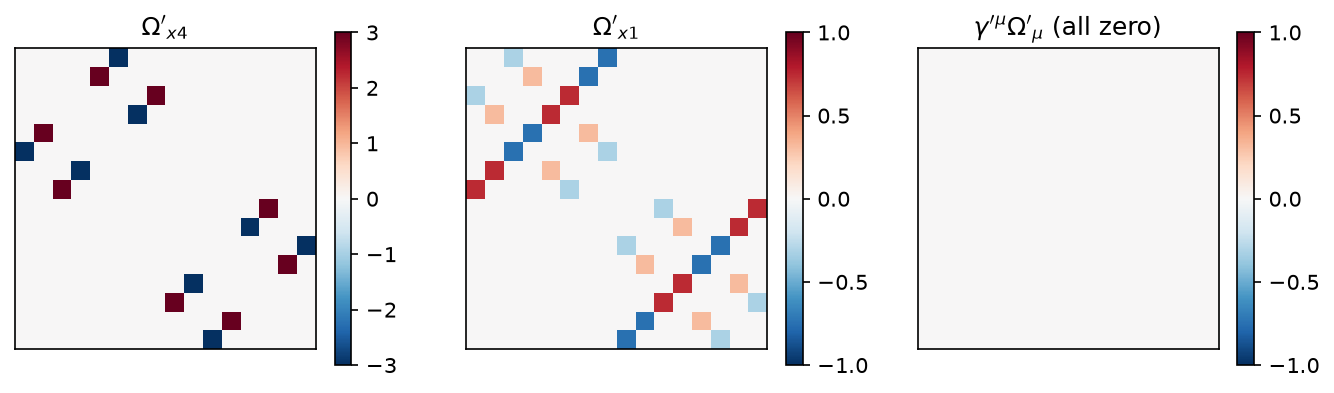

Figure 06b.3 saved as Revision/textbook/figures/06b_3_boosted_connection_heat_maps.png
PASS at the sample point Omega'_x4 is nonzero and the contraction is zero


In [11]:
def at_sample(expr):
    """The decimal value of expr at H = 1, b0 = 0, x4 = 1/6, z = pi/4, a4 = 1/2,
    a4' = 1/2, a4'' = 0 (derivatives replaced first, then a4, then x4)."""
    expr = sp.sympify(expr).subs(sp.Derivative(a4, (x4, 2)), 0)
    expr = expr.subs(sp.Derivative(a4, x4), sp.Rational(1, 2))
    expr = expr.subs(a4, sp.Rational(1, 2))
    expr = expr.subs({H: 1, b0: 0, x4: sp.Rational(1, 6), x8: sp.pi / 24})
    return float(sp.N(expr))


def sample_table(matrix):
    return np.array([[at_sample(v) for v in row] for row in matrix.tolist()])


panels = [("$\\Omega'_{x4}$", Omega_6H[3]), ("$\\Omega'_{x1}$", Omega_6H[0]),
          ("$\\gamma'^\\mu\\Omega'_\\mu$ (all zero)", slash_6H)]
tables = [sample_table(M) for _, M in panels]
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
for ax, (title, _), table in zip(axes, panels, tables):
    limit = max(np.abs(table).max(), 1.0)  # each panel its own colour scale
    image = ax.imshow(table, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    fig.colorbar(image, ax=ax, shrink=0.8)
save_figure(fig, "boosted_connection_heat_maps",
            "The boosted vielbein with the rate $\\beta = 6H$ at the sample point "
            "$H = 1$, $b_0 = 0$, $x_4 = 1/6$ (rapidity $b = 1$), $z = \\pi/4$, $a_4 = "
            "1/2$, $a_4' = 1/2$, as 16 x 16 heat maps (red positive, blue negative, "
            "white zero; rows and columns are the spinor components; each panel has "
            "its own colour scale). Left: "
            "$\\Omega'_{x4}$, nonzero because the frame turns with time; middle: "
            "$\\Omega'_{x1}$; right: the contraction $\\gamma'^\\mu\\Omega'_\\mu$, the "
            "zero matrix. The spinor connection is present, its contraction is not.")
check(np.abs(tables[2]).max() < 1e-12 and np.abs(tables[0]).max() > 0.1,
      "at the sample point Omega'_x4 is nonzero and the contraction is zero")

## 11. Why: the local spin covariance, with an explicit spinor boost

The next cell takes the 16 x 16 matrix $X = \gamma^{(x4)}\gamma^{(x8)}$. Since
$X^2 = -\gamma^{(x4)}\gamma^{(x4)}\gamma^{(x8)}\gamma^{(x8)} = -(-1)(+1) = 1$,
the spinor boost $R = \cosh\frac b2 - \sinh\frac b2\,X$ has the inverse
$R^{-1} = \cosh\frac b2 + \sinh\frac b2\,X$ (multiply them: $\cosh^2 -
\sinh^2 X^2 = 1$). The cell checks, exactly:

1. $R^{-1}\gamma^a R = \sum_c\Lambda^a{}_c\gamma^c$ for all eight $a$: $R$
   covers the boost $\Lambda(b)$;
2. $\gamma'^\mu = R\,\gamma^\mu R^{-1}$ and $\Omega'_\mu = R\,\Omega_\mu R^{-1} -
   (\partial_\mu R)R^{-1}$ for all eight $\mu$ (the covariance theorem);
3. the two pieces of the formula of Section 9: $R\,(3H\gamma^{(x8)})\,R^{-1} =
   3H(\cosh b\,\gamma^{(x8)} - \sinh b\,\gamma^{(x4)})$, and the extra term
   $\sum_\mu\gamma'^\mu(\partial_\mu R)R^{-1} = \frac{\beta}{2}(\cosh b\,
   \gamma^{(x8)} - \sinh b\,\gamma^{(x4)})$ (only $\mu = x4$ contributes, because
   $R$ depends on $x_4$ only). Their difference is the record's formula.

In [12]:
X = gamma[3] * gamma[7]  # gamma^(x4) gamma^(x8)
check(X * X == I16, "X = gamma^(x4) gamma^(x8) squares to the identity")
R = sp.cosh(b / 2) * I16 - sp.sinh(b / 2) * X  # the spinor boost
R_inv = sp.cosh(b / 2) * I16 + sp.sinh(b / 2) * X
check(matrix_is_zero(R * R_inv - I16), "R R^-1 = 1")
covers = all(matrix_is_zero(R_inv * gamma[a] * R
                            - sum((L[a, c] * gamma[c] for c in range(8)), Z16))
             for a in range(8))
check(covers, "R^-1 gamma^a R = Lambda^a_c gamma^c: R covers the boost")
gammas_turn = all(matrix_is_zero(gup_b[mu] - R * gup[mu] * R_inv) for mu in range(8))
connection_rule = all(matrix_is_zero(Omega_b[mu] - (R * Omega[mu] * R_inv
                                                   - R.diff(x[mu]) * R_inv))
                      for mu in range(8))
check(gammas_turn and connection_rule,
      "gamma'^mu = R gamma^mu R^-1 and Omega'_mu = R Omega_mu R^-1 - (d_mu R) R^-1")
turned = R * (3 * H * gamma[7]) * R_inv
extra = sum((gup_b[mu] * R.diff(x[mu]) * R_inv for mu in range(8)), Z16)
direction = sp.cosh(b) * gamma[7] - sp.sinh(b) * gamma[3]
check(matrix_is_zero(turned - 3 * H * direction)
      and matrix_is_zero(extra - beta / 2 * direction),
      "R (3H g8) R^-1 = 3H v and extra term = (beta/2) v, v = cosh b g8 - sinh b g4")

PASS X = gamma^(x4) gamma^(x8) squares to the identity
PASS R R^-1 = 1
PASS R^-1 gamma^a R = Lambda^a_c gamma^c: R covers the boost
PASS gamma'^mu = R gamma^mu R^-1 and Omega'_mu = R Omega_mu R^-1 - (d_mu R) R^-1
PASS R (3H g8) R^-1 = 3H v and extra term = (beta/2) v, v = cosh b g8 - sinh b g4


## 12. The curvature: the Riemann and Ricci tensors

The next cell computes the Riemann tensor of the author's metric from the
Christoffel symbols with the convention $R^\rho{}_{\sigma\mu\nu} =
\partial_\mu\Gamma^\rho{}_{\nu\sigma} - \partial_\nu\Gamma^\rho{}_{\mu\sigma} +
\sum_\lambda(\Gamma^\rho{}_{\mu\lambda}\Gamma^\lambda{}_{\nu\sigma} -
\Gamma^\rho{}_{\nu\lambda}\Gamma^\lambda{}_{\mu\sigma})$ (it keeps the components
with $\mu < \nu$; the others follow from the antisymmetry in $\mu, \nu$), then the
mixed Ricci components $R^\mu{}_\mu$ and the Ricci scalar, and compares them with
the record (`ricci_mixed_diagonal`, `ricci_scalar`). The record's values are

$$R^{x1}{}_{x1} = R^{x2}{}_{x2} = R^{x3}{}_{x3} = a_4'' - 6H^2,\quad
R^{x4}{}_{x4} = 6a_4'^2,\quad R^{x5}{}_{x5} = R^{x6}{}_{x6} = R^{x7}{}_{x7} =
-a_4'' - 6H^2,\quad R^{x8}{}_{x8} = -6H^2,$$

and $R = 6(a_4'^2 - 7H^2)$. The component $R^{x8}{}_{x8} = -6H^2$ is negative for
every $H > 0$ and every $a_4$: the metric is never flat. The component
$R^{x4}{}_{x4} = 6a_4'^2$ shows that the deflation makes curvature, although
$\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$ does not contain $a_4$ at all.

In [13]:
def riemann_component(r, sg, mu, nu):
    value = sp.diff(Gam[r][nu][sg], x[mu]) - sp.diff(Gam[r][mu][sg], x[nu])
    for lam in range(8):
        value += Gam[r][mu][lam] * Gam[lam][nu][sg] - Gam[r][nu][lam] * Gam[lam][mu][sg]
    return value


def is_nonzero(expr):
    """True when expr is not identically zero.  A value clearly different from zero
    at the sample point proves it (fast); otherwise the exact test decides."""
    if abs(at_sample(expr)) > 1e-9:
        return True
    return not is_zero(expr)


riemann = {}  # (r, sigma, mu, nu) -> R^r_sigma mu nu, only the nonzero ones
for r in range(8):
    for sg in range(8):
        for mu in range(8):
            for nu in range(mu + 1, 8):
                value = riemann_component(r, sg, mu, nu)
                if value != 0 and is_nonzero(value):
                    riemann[(r, sg, mu, nu)] = value
                    riemann[(r, sg, nu, mu)] = -value
report("nonzero components R^r_sigma mu nu with mu < nu", len(riemann) // 2)
ricci_mixed = [sum(riemann.get((r, a, r, a), 0) for r in range(8)) / g[a, a]
               for a in range(8)]  # R^a_a = g^aa R_aa
names = {"H": H, "a4p": sp.Derivative(a4, x4), "a4pp": sp.Derivative(a4, (x4, 2))}
FORMULAS = {item["key"]: item["wl"] for item in json.loads(
    repository_file(THEORY_FILE).read_text(encoding="utf-8"))["formulas"]}


def record_formula(key):
    text = FORMULAS[key]
    for long_form, short_form in (("Derivative[1][a4][x4]", "a4p"),
                                  ("Derivative[2][a4][x4]", "a4pp")):
        text = text.replace(long_form, short_form)
    return parse_mathematica(text).subs(
        {sp.Symbol(k): v for k, v in names.items()}, simultaneous=True)


ricci_record = record_formula("ricci_mixed_diagonal")
check(all(is_zero(ricci_mixed[a] - ricci_record[a]) for a in range(8)),
      "the eight Ricci components R^mu_mu equal the record",
      record=f"{THEORY_FILE}, formula ricci_mixed_diagonal")
for a in range(8):
    say(f"R^{NAMES[a]}_{NAMES[a]} = {ricci_record[a]}")
ricci_scalar = sum(ricci_mixed)
check(is_zero(ricci_scalar - record_formula("ricci_scalar")),
      "the Ricci scalar R = 6 (a4'^2 - 7 H^2) equals the record",
      record=f"{THEORY_FILE}, formula ricci_scalar")
a4_free = all(sp.diff(entry, sp.Derivative(a4, x4)) == 0 and not entry.has(a4)
              for entry in slash)
check(a4_free and is_zero(ricci_mixed[7] + 6 * H**2)
      and is_zero(ricci_mixed[3] - 6 * sp.Derivative(a4, x4) ** 2),
      "gamma^mu Omega_mu contains no a4, but R^x4_x4 = 6 a4'^2; R^x8_x8 = -6 H^2",
      record=f"{SCOPE_PY}, check gammaOmega_blind_to_the_deflation")

RESULT nonzero components R^r_sigma mu nu with mu < nu = 78
PASS the eight Ricci components R^mu_mu equal the record
     reproduces Revision/theory/field-theory.json, formula ricci_mixed_diagonal
R^x1_x1 = -6*H**2 + Derivative(a4(x4), (x4, 2))
R^x2_x2 = -6*H**2 + Derivative(a4(x4), (x4, 2))
R^x3_x3 = -6*H**2 + Derivative(a4(x4), (x4, 2))
R^x4_x4 = 6*Derivative(a4(x4), x4)**2
R^x5_x5 = -6*H**2 - Derivative(a4(x4), (x4, 2))
R^x6_x6 = -6*H**2 - Derivative(a4(x4), (x4, 2))
R^x7_x7 = -6*H**2 - Derivative(a4(x4), (x4, 2))
R^x8_x8 = -6*H**2
PASS the Ricci scalar R = 6 (a4'^2 - 7 H^2) equals the record
     reproduces Revision/theory/field-theory.json, formula ricci_scalar
PASS gamma^mu Omega_mu contains no a4, but R^x4_x4 = 6 a4'^2; R^x8_x8 = -6 H^2
     reproduces Revision/theory/reports/python-scope.json, check
    gammaOmega_blind_to_the_deflation


The next cell draws the Ricci components. On the left, the eight values
$R^\mu{}_\mu$ at the sample values $H = 1$, $a_4' = 1/2$, $a_4'' = 0$ (in units of
$H^2$). On the right, three of them as functions of the rate $a_4'$ (with
$a_4'' = 0$): the hidden component $-6H^2$ does not depend on the history, the time
component $6a_4'^2$ is made entirely by the expansion and deflation, and the
3-space component $a_4'' - 6H^2$ stays $-6H^2$ for a steady rate ($a_4'' = 0$).

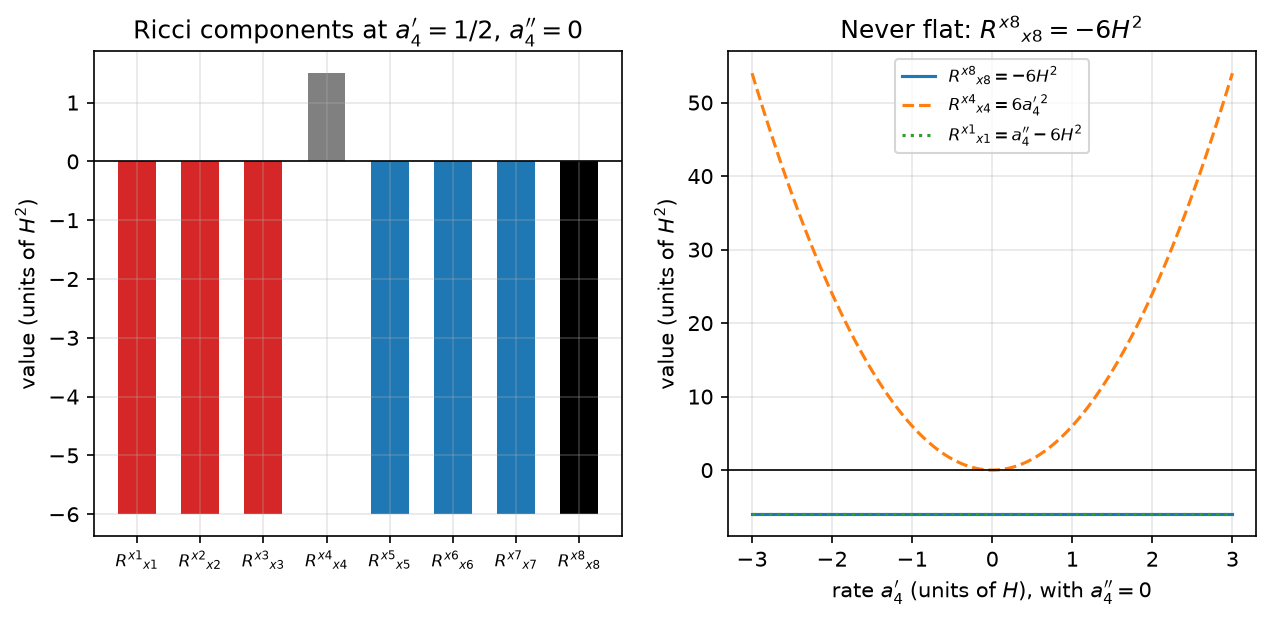

Figure 06b.4 saved as Revision/textbook/figures/06b_4_ricci_components.png


In [14]:
rate_symbol, accel_symbol = sp.symbols("rate accel", real=True)
numeric = [sp.lambdify((rate_symbol, accel_symbol), ricci_record[a].subs(
    {H: 1, sp.Derivative(a4, (x4, 2)): accel_symbol,
     sp.Derivative(a4, x4): rate_symbol})) for a in range(8)]
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
values = [float(numeric[a](0.5, 0.0)) for a in range(8)]
colors = ["tab:red"] * 3 + ["gray"] + ["tab:blue"] * 3 + ["black"]
ax_left.bar(range(8), values, color=colors, width=0.6)
ax_left.axhline(0.0, color="black", linewidth=0.8)
ax_left.set_xticks(range(8), [f"$R^{{{n}}}{{}}_{{{n}}}$" for n in NAMES], fontsize=8)
ax_left.set_ylabel("value (units of $H^2$)")
ax_left.set_title("Ricci components at $a_4' = 1/2$, $a_4'' = 0$")
rates = np.linspace(-3.0, 3.0, 121)
for a, label, style in ((7, "$R^{x8}{}_{x8} = -6H^2$", "-"),
                        (3, "$R^{x4}{}_{x4} = 6a_4'^2$", "--"),
                        (0, "$R^{x1}{}_{x1} = a_4'' - 6H^2$", ":")):
    ax_right.plot(rates, np.broadcast_to(numeric[a](rates, 0.0), rates.shape),
                  style, label=label)
ax_right.axhline(0.0, color="black", linewidth=0.8)
ax_right.set_xlabel("rate $a_4'$ (units of $H$), with $a_4'' = 0$")
ax_right.set_ylabel("value (units of $H^2$)")
ax_right.set_title("Never flat: $R^{x8}{}_{x8} = -6H^2$")
ax_right.legend(fontsize=8)
save_figure(fig, "ricci_components",
            "The mixed Ricci components $R^\\mu{}_\\mu$ of the author's metric in "
            "units of $H^2$. Left: all eight at $H = 1$, $a_4' = 1/2$, "
            "$a_4^{\\prime\\prime} = 0$ (red: 3-space, gray: time, blue: extra times, "
            "black: hidden direction). Right: $R^{x8}{}_{x8} = -6H^2$ (solid), "
            "$R^{x4}{}_{x4} = 6a_4'^2$ (dashed) and $R^{x1}{}_{x1} = "
            "a_4^{\\prime\\prime} - 6H^2$ (dotted) versus the rate $a_4'$ in units of "
            "$H$ with $a_4^{\\prime\\prime} = 0$. The hidden component "
            "is negative for every history, so the metric is never flat, and the "
            "time component is curvature made by the expansion and deflation (the "
            "dotted line lies on the solid one because $a_4^{\\prime\\prime} = 0$).")

## 13. The curvature of the spinor connection

The next cell computes, in the diagonal vielbein, the 28 matrices $F_{\mu\nu}$
($\mu < \nu$) and checks the theorem $F_{\mu\nu} = \frac12\sum_{a,b}
R_{ab\mu\nu}S^{ab}$, where $R_{ab\mu\nu} = \eta_{aa}\,f_a\,R^a{}_{b\mu\nu}/f_b$
is the Riemann tensor with two frame indices (for the diagonal vielbein). Then it
computes $F'_{x1\,x8}$ in the boosted vielbein with $\beta = 6H$ (where the
contraction vanished) and checks that it is $R\,F_{x1\,x8}R^{-1}$ and is not zero:
the spinor connection is still there and curved.

In [15]:
def spinor_curvature(Om, mu, nu):
    return (Om[nu].diff(x[mu]) - Om[mu].diff(x[nu])
            + Om[mu] * Om[nu] - Om[nu] * Om[mu])


F = {}
theorem_ok = True
for mu in range(8):
    for nu in range(mu + 1, 8):
        F[(mu, nu)] = spinor_curvature(Omega, mu, nu)
        from_riemann = sum((ETA[a] * f[a] * riemann[(a, c, mu, nu)] / f[c] * S[a][c] / 2
                            for a in range(8) for c in range(8)
                            if (a, c, mu, nu) in riemann), Z16)
        theorem_ok = theorem_ok and matrix_is_zero(F[(mu, nu)] - from_riemann)
check(theorem_ok, "F_mu nu = (1/2) R_ab mu nu S^ab in all 28 coordinate planes",
      record=f"{REPORT_PY}, check spinor_curvature_equals_riemann")
F18_boosted = spinor_curvature(Omega_6H, 0, 7)
R_6H, R_inv_6H = R.subs(six_H), R_inv.subs(six_H)
check(matrix_is_zero(F18_boosted - R_6H * F[(0, 7)] * R_inv_6H)
      and np.abs(sample_table(F18_boosted)).max() > 0.1,
      "boosted (beta = 6H): F'_x1x8 = R F_x1x8 R^-1, nonzero",
      record=f"{SCOPE_PY}, check boosted_frame_curvature_nonzero")

PASS F_mu nu = (1/2) R_ab mu nu S^ab in all 28 coordinate planes
     reproduces Revision/theory/reports/python-field-theory.json, check
    spinor_curvature_equals_riemann
PASS boosted (beta = 6H): F'_x1x8 = R F_x1x8 R^-1, nonzero
     reproduces Revision/theory/reports/python-scope.json, check
    boosted_frame_curvature_nonzero


The next cell draws the size of the spinor curvature in each coordinate plane: for
every pair $(\mu, \nu)$ the number $\|F_{\mu\nu}\| = \sqrt{\sum_{i,j}
(F_{\mu\nu})_{ij}^2}$ (the square root of the sum of the squares of the 256
entries) at the sample point $H = 1$, $z = \pi/4$, $a_4 = 1/2$, $a_4' = 1/2$,
$a_4^{\prime\prime} = 0$ (diagonal vielbein). In another frame
$F'_{\mu\nu} = R\,F_{\mu\nu}R^{-1}$ with an invertible matrix $R$, so a change of
frame can change the sizes, but it can never turn a coloured square white or a
white square coloured.

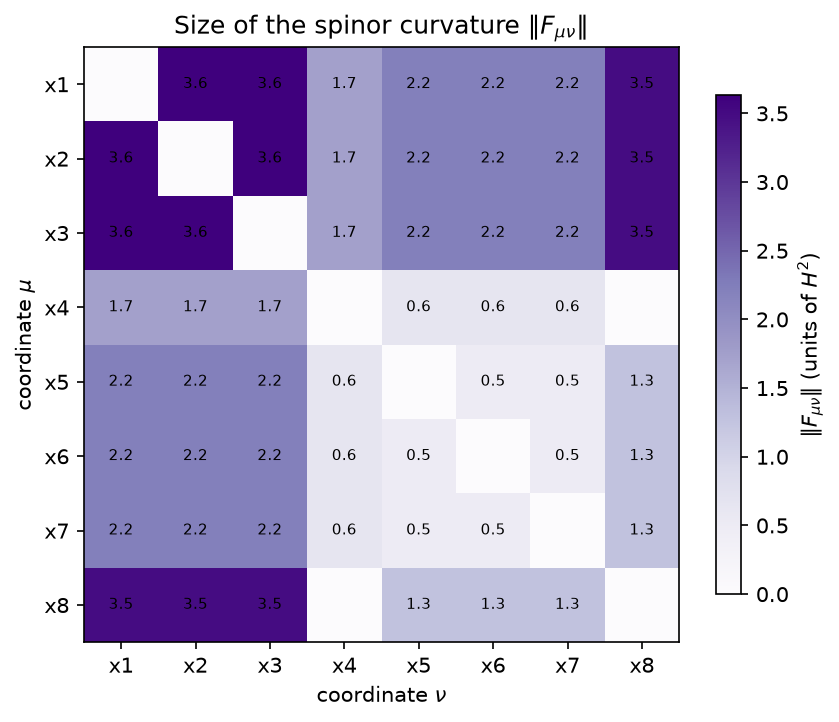

Figure 06b.5 saved as Revision/textbook/figures/06b_5_spinor_curvature_norms.png
RESULT largest |F_mu nu| at the sample point (units of H^2) = 3.633
PASS F_x4x8 = 0 exactly; the other 27 planes are curved at the sample point


In [16]:
norms = np.zeros((8, 8))
for (mu, nu), matrix in F.items():
    norms[mu, nu] = norms[nu, mu] = np.sqrt((sample_table(matrix) ** 2).sum())
fig, ax = plt.subplots(figsize=(6.4, 5.4))
image = ax.imshow(norms, cmap="Purples")
for mu in range(8):
    for nu in range(8):
        if norms[mu, nu] > 0:
            ax.text(nu, mu, f"{norms[mu, nu]:.1f}", ha="center", va="center",
                    fontsize=7, color="black" if norms[mu, nu] < 8 else "white")
ax.set_xticks(range(8), NAMES)
ax.set_yticks(range(8), NAMES)
ax.set_xlabel("coordinate $\\nu$")
ax.set_ylabel("coordinate $\\mu$")
ax.set_title("Size of the spinor curvature $\\|F_{\\mu\\nu}\\|$")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="$\\|F_{\\mu\\nu}\\|$ (units of $H^2$)")
save_figure(fig, "spinor_curvature_norms",
            "The size $\\|F_{\\mu\\nu}\\|$, the square root of the sum of the squares "
            "of the 256 entries of the spinor curvature, for every pair of "
            "coordinates $(\\mu, \\nu)$ in the diagonal vielbein at the sample point "
            "$H = 1$, $z = \\pi/4$, $a_4 = 1/2$, $a_4' = 1/2$, "
            "$a_4^{\\prime\\prime} = 0$, in units "
            "of $H^2$ (darker is larger, white is zero). All 28 coordinate planes "
            "except the plane of the time $x4$ and the hidden direction $x8$ are "
            "curved at this point, and $F_{x4\\,x8} = 0$ exactly; $F_{\\mu\\nu} = "
            "\\frac12 R_{ab\\mu\\nu}S^{ab}$ is the Riemann curvature, which no "
            "change of frame removes.")
report("largest |F_mu nu| at the sample point (units of H^2)", f"{norms.max():.3f}")
curved = [pair for pair in F if norms[pair] > 1e-9]  # the curved planes
check(matrix_is_zero(F[(3, 7)]) and len(curved) == 27,
      "F_x4x8 = 0 exactly; the other 27 planes are curved at the sample point")

## 14. The rescaling $\Psi = \sin^{-1/2}(z)\,\chi$ removes the term

A frame change is one way to remove $3H\gamma^{(x8)}$; a change of the field
variable is another. Write $\Psi = w\,\chi$ with $w = \sin^{-1/2}z$. Then
$\gamma^\mu D_\mu\Psi = w\,\gamma^\mu\partial_\mu\chi + \big(\gamma^\mu
\partial_\mu w + w\,\gamma^\mu\Omega_\mu\big)\chi$. Only $x_8$ appears in $w$, and
$\gamma^{x8} = \tan z\,\gamma^{(x8)}$, so the bracket is $\big(\tan z\,
\partial_{x8}w + 3H w\big)\gamma^{(x8)}$, and $\partial_{x8}\sin^{-1/2}z =
-\frac12\sin^{-3/2}z\cdot 6H\cos z$ gives $\tan z\,\partial_{x8}w = -3Hw$: the
bracket is zero. The next cell checks this as a matrix identity and, for safety,
on 16 completely general functions $\chi_1, \dots, \chi_{16}$ of all eight
coordinates. It also checks the record's remark about the potential
$U = \frac{\lambda}{2}S^2$: since $w$ is real, $S[\Psi] = \Psi^\dagger C\Psi =
w^2\,S[\chi] = S[\chi]/\sin z$, so the rescaled equation is $\gamma^\mu
\partial_\mu\chi = (m + \lambda S[\chi]/\sin z)\,\chi$: for $U = 0$ the term is
removed completely; for $U \ne 0$ it becomes a coupling that depends on $x_8$.

In [17]:
w = sp.sin(z) ** sp.Rational(-1, 2)  # the weight sin^(-1/2) z
bracket = sum((gup[mu] * sp.diff(w, x[mu]) for mu in range(8)), Z16) + w * slash
chi = sp.Matrix([sp.Function(f"chi{A}")(*x) for A in range(1, 17)])
psi = w * chi
dirac_psi = sum((gup[mu] * (psi.diff(x[mu]) + Omega[mu] * psi) for mu in range(8)),
                sp.zeros(16, 1))
dirac_chi = sum((gup[mu] * chi.diff(x[mu]) for mu in range(8)), sp.zeros(16, 1))
check(matrix_is_zero(bracket) and all(is_zero(v) for v in dirac_psi - w * dirac_chi),
      "gamma^mu D_mu (w chi) = w gamma^mu d_mu chi for w = sin^(-1/2) z",
      record=f"{SCOPE_PY}, check rescaling_removes_the_connection_term")
chi_conj = sp.Matrix([sp.conjugate(v) for v in chi])  # complex conjugates
S_psi = (w * chi_conj).T * C * (w * chi)  # Psi^dagger C Psi (w is real)
S_chi = chi_conj.T * C * chi
check(is_zero(S_psi[0, 0] - S_chi[0, 0] / sp.sin(z)),
      "S[sin^(-1/2) z chi] = S[chi] / sin z",
      record=f"{SCOPE_PY}, check rescaled_equation_quadratic_potential")

PASS gamma^mu D_mu (w chi) = w gamma^mu d_mu chi for w = sin^(-1/2) z
     reproduces Revision/theory/reports/python-scope.json, check
    rescaling_removes_the_connection_term
PASS S[sin^(-1/2) z chi] = S[chi] / sin z
     reproduces Revision/theory/reports/python-scope.json, check
    rescaled_equation_quadratic_potential


The next cell draws the rescaling for $H = 1$: on the left the weight
$w = \sin^{-1/2}z$ (large near the tip $z \to 0$, equal to 1 at $z = \pi/2$); on
the right the two terms of the bracket, $\tan z\,\partial_{x8}w$ and $3Hw$,
computed from their sympy formulas, and their sum, which is zero at every $z$.

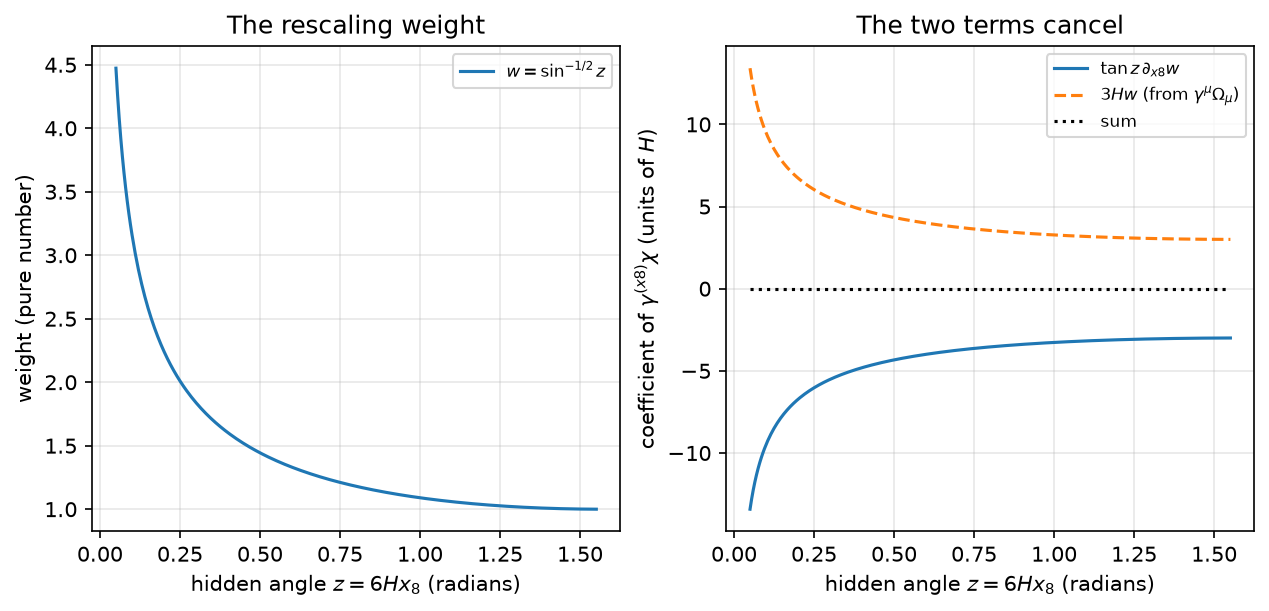

Figure 06b.6 saved as Revision/textbook/figures/06b_6_rescaling.png
PASS the two terms cancel at all 300 points


In [18]:
z_values = np.linspace(0.05, np.pi / 2 - 0.02, 300)
x8_symbol = sp.Symbol("u", positive=True)
term_derivative = sp.lambdify(x8_symbol, (sp.tan(z) * sp.diff(w, x8)).subs(
    {H: 1}).subs(x8, x8_symbol))
term_connection = sp.lambdify(x8_symbol, (3 * H * w).subs({H: 1}).subs(x8, x8_symbol))
weight = sp.lambdify(x8_symbol, w.subs({H: 1}).subs(x8, x8_symbol))
u_values = z_values / 6.0  # x8 = z / (6 H) with H = 1
first, second = term_derivative(u_values), term_connection(u_values)
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
ax_left.plot(z_values, weight(u_values), label="$w = \\sin^{-1/2} z$")
ax_left.set_xlabel("hidden angle $z = 6Hx_8$ (radians)")
ax_left.set_ylabel("weight (pure number)")
ax_left.set_title("The rescaling weight")
ax_left.legend(fontsize=8)
ax_right.plot(z_values, first, label="$\\tan z\\,\\partial_{x8} w$")
ax_right.plot(z_values, second, "--", label="$3H w$ (from $\\gamma^\\mu\\Omega_\\mu$)")
ax_right.plot(z_values, first + second, ":", color="black", label="sum")
ax_right.set_xlabel("hidden angle $z = 6Hx_8$ (radians)")
ax_right.set_ylabel("coefficient of $\\gamma^{(x8)}\\chi$ (units of $H$)")
ax_right.set_title("The two terms cancel")
ax_right.legend(fontsize=8)
save_figure(fig, "rescaling",
            "The rescaling $\\Psi = w\\chi$ with $w = \\sin^{-1/2}z$ and $H = 1$. "
            "Left: the weight $w$ versus the hidden angle $z$ in radians. Right: the "
            "two terms of the coefficient of $\\gamma^{(x8)}\\chi$ in the field "
            "equation of $\\chi$, the derivative term $\\tan z\\,\\partial_{x8}w = "
            "-3Hw$ (solid) and the spin-connection term $3Hw$ (dashed), in units of "
            "$H$, and their sum (dotted), which is zero at every $z$: in the "
            "variable $\\chi$ the equation has no term $3H\\gamma^{(x8)}$.")
check(np.max(np.abs(first + second)) < 1e-12, "the two terms cancel at all 300 points")

## 15. The last checks

The last cell checks that every check of the Revision reports that states a result
reproduced in this notebook is recorded there as passed (the sympy scope checker
`python-scope.json`, the WolframScript scope checker `wolfram-scope.json`, which
shares no code with it, and the curvature checks of the field-theory reports),
that all six figure files exist in the folder Revision/textbook/figures, and
prints the number of checks that passed.

In [19]:
scope_names = ["boosted_frame_reproduces_metric", "boosted_frame_canonical_connection",
               "boosted_frame_gammaOmega_formula", "boosted_frame_gammaOmega_vanishes",
               "boosted_frame_curvature_nonzero",
               "rescaling_removes_the_connection_term",
               "rescaled_equation_quadratic_potential",
               "gammaOmega_blind_to_the_deflation"]
cited = {SCOPE_PY: scope_names, SCOPE_WL: scope_names,
         REPORT_PY: ["spinor_curvature_equals_riemann",
                     "curvature_nonzero_flat_only_formally"],
         REPORT_WL: ["ricci_scalar", "ricci_mixed_components",
                     "never_flat_for_H_positive", "spin_curvature_equals_Riemann"]}
count = sum(len(v) for v in cited.values())
check(all(record_passed(path, name) for path, names in cited.items()
          for name in names), f"the {count} cited record checks are recorded as passed")
expected = [f"06b_{k}_{name}.png" for k, name in enumerate([
    "boost_hyperbolas", "boosted_contraction", "boosted_connection_heat_maps",
    "ricci_components", "spinor_curvature_norms", "rescaling"], 1)]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in expected),
      "all six figure files exist")
all_checks_passed()

PASS the 22 cited record checks are recorded as passed
PASS all six figure files exist
ALL 26 CHECKS PASSED (notebook 06b)


## 16. What this notebook showed

- A boost of the frame in the $(x4, x8)$ plane with rapidity $b = \beta x_4 + b_0$
  describes the same metric, and its canonical spin connection obeys the vielbein
  postulate. In it $\gamma'^\mu\Omega'_\mu = \frac{6H-\beta}{2}(\cosh b\,
  \gamma^{(x8)} - \sinh b\,\gamma^{(x4)})$ exactly (PROVED; reproduces the
  record). For $\beta = 6H$ the contraction vanishes identically, while
  $\Omega'_\mu$ is nonzero for $\mu = x1, \dots, x7$.
- The reason is the local spin covariance: with the spinor boost
  $R = \cosh\frac b2 - \sinh\frac b2\,\gamma^{(x4)}\gamma^{(x8)}$, $\Omega'_\mu =
  R\Omega_\mu R^{-1} - (\partial_\mu R)R^{-1}$, and the second term contributes
  $-\frac{\beta}{2}(\cosh b\,\gamma^{(x8)} - \sinh b\,\gamma^{(x4)})$ (PROVED
  here).
- So the value $3H\gamma^{(x8)}$ of the diagonal vielbein is FRAME-DEPENDENT. What
  is frame-independent: the metric is curved for every $H > 0$ ($R^{x8}{}_{x8} =
  -6H^2$, PROVED; reproduces the record), the spinor curvature is $F_{\mu\nu} =
  \frac12 R_{ab\mu\nu}S^{ab}$ in all 28 planes (PROVED; reproduces the record), and
  it is nonzero in every frame because $F' = RFR^{-1}$; therefore no frame makes
  $\Omega_\mu$ vanish.
- The deflation makes curvature ($R^{x4}{}_{x4} = 6a_4'^2$) that the contraction
  $\gamma^\mu\Omega_\mu$ does not see (PROVED; reproduces the record).
- The rescaling $\Psi = \sin^{-1/2}(z)\,\chi$ removes the term $3H\gamma^{(x8)}$
  from the field equation exactly; with $U = \frac\lambda2 S^2$ it becomes the
  coupling $\lambda S[\chi]/\sin z$ (PROVED; reproduces the record).
- In short, the non-triviality of the field equations holds in the qualified sense
  of the record: the gravitational field enters through the vielbein factors of
  every derivative term and through a spin connection whose curvature cannot be
  removed, but the particular term $3H\gamma^{(x8)}$ is a property of the chosen
  frame and field variables.